# Instructions to use:

1. In the globals settings select which TMA core you want to compute (A, B, or C). This is the only variable you need to change. 
2. Run the helper functions cell.
3. Run the data Load to load in that core's data.
4. Run the rest of the cells down in order. (The mRNA main execution will take a few minutes)
   

## Gloabl Settings

In [76]:
TMA_Core="B" # Should be A,B,C This is the only variable you need to change.

## Data Load

In [77]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

### Load mRNA files ###
#Load files 
expr = pd.read_csv(fr"data/RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
metadata = pd.read_csv(fr"data/RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
umap = pd.read_csv(fr"data/RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

# Extra - MetaData File
extra_metadata = pd.read_csv(fr"data/Run_TMA{TMA_Core}_metadata_file.csv", index_col=0)

# Create AnnData object
adata_rna = sc.AnnData(X=expr.values)

# Assign metadata
adata_rna.obs = metadata
adata_rna.var_names = expr.columns
adata_rna.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata_rna.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
adata_rna.obsm["X_umap"] = umap.values


### Load Protein files ###
# Only create adata if it doesn't already exist
if "adata" not in globals():
    # Load files 
    expr_orig = pd.read_csv("data/protein_expression.csv", index_col=0)
    expr = expr_orig.transpose()
    metadata = pd.read_csv("data/protein_metadata.csv", index_col=0)
    umap = pd.read_csv("data/protein_umap.csv", index_col=0)

    # Create AnnData object
    adata = sc.AnnData(X=expr.values)

    # Assign metadata
    adata.obs = metadata
    adata.var_names = expr.columns
    adata.obs_names = expr.index

    # Add spatial coordinates and UMAP to .obsm
    adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px=-metadata['y_FOV_px']).values

C:\Users\evanj\AppData\Local\Temp\ipykernel_19964\1802742535.py:9: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(fr"data/RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)


## Helper Functions 

In [61]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re

def find_area_mRNA(adata,sample_id):
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]
    
    x_max=0.0
    y_max=0.0
    x_min=100000000
    y_min=100000000
    area=0.0
    number_of_cells=0
    
    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        results
        x=abs(row["x_pixel"])
        y=abs(row["y_pixel"])
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    

     #Covert to microns
    x_max=x_max*0.168
    y_max=y_max*0.168
    x_min=x_min*0.168
    y_min=y_min*0.168

    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")

    # Area in microns squared 
    area=(x_max-x_min)*(y_max-y_min)
    
    return area
# Function to get the global coordinates
def find_matching_global_coords(extra_metadata, cell_num, FOV_num):
    import numpy as np
    import pandas as pd
    
    # Ensure the index is reset so FOV becomes a column (if needed)
    filtered_row = extra_metadata.reset_index()
    filtered_row = filtered_row[(filtered_row['fov'] == FOV_num) & (filtered_row['cell_ID'] == cell_num)]

    if filtered_row.empty:
        print(f"No match found for FOV={FOV_num} and cell_ID={cell_num}.")
        return None

    global_x = filtered_row['CenterX_global_px'].values[0] * 0.168 * 0.001
    global_y = filtered_row['CenterY_global_px'].values[0] * 0.168 * 0.001

    return {
        "Global X": global_x,
        "Global Y": global_y
    }

def find_area_mRNA_global_coords(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]

    print(sample_id)
    
    # Initialize min and max values to properly handle negative coordinates
    x_max = -10000000000000000000000000000000000000000
    y_max = -10000000000000000000000000000000000000000
    x_min = 10000000000000000000000000000000000000000
    y_min = 10000000000000000000000000000000000000000
    number_of_cells=0
    
     #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        
        # Updated regular expression: \d+ for Run, [A-Za-z] for the TMA letter
        match = re.search(r'_Run\d+\.TMA[A-Za-z]_(\d+)_(\d+)', cell_id)
        cell_num = int(match.group(1))
        FOV_num = int(match.group(2))

        # Get the global coordinates
        results=find_matching_global_coords(extra_metadata,cell_num,FOV_num)
        x=results["Global X"]
        y=results["Global Y"]
        
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")
    
    return{
        "X Max":x_max,
        "X Min":x_min,
        "Y Max":y_max,
        "Y Min":y_min
    }


def plot_spatial_rectangles_mRNA2(dataframe, ax=None):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
        ax (matplotlib.axes.Axes, optional): Matplotlib Axes object to plot on. 
                                             If None, a new figure and axes are created.
    """
    # Create a new figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        show_plot = True
    else:
        show_plot = False

    for _, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        rect = patches.Rectangle(
            (x_min, y_min),
            x_length,
            y_length,
            linewidth=1.5,
            edgecolor='royalblue',
            facecolor='skyblue',
            alpha=0.6
        )
        ax.add_patch(rect)
        ax.text(
            x_min + x_length / 2,
            y_min + y_length / 2,
            sample_id,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold'
        )

    # Styling
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    #ax.invert_xaxis()
    ax.autoscale_view()
    ax.grid(True, linestyle='--', alpha=0.5)

    if show_plot:
        plt.tight_layout()
        plt.show()

def find_area_protein_global_coords_optimized(adata, sample_id):
    """
    An optimized function to find the min/max spatial coordinates for a given sample.
    This version uses pandas' built-in, vectorized functions (.min(), .max()) 
    which are significantly faster than iterating through rows.
    
    Args:
        adata (anndata.AnnData): The AnnData object containing cell data.
        sample_id (str): The identifier for the sample to analyze.
        
    Returns:
        dict: A dictionary with the min/max x and y coordinates.
    """
    # Filter the AnnData object to only the cells from this sample
    protein_subset_obs = adata.obs[adata.obs.index.str.startswith(sample_id)]
    
    if protein_subset_obs.empty:
        print(f"Warning: No cells found for sample ID: {sample_id}")
        return {
            "X Max": np.nan, "X Min": np.nan,
            "Y Max": np.nan, "Y Min": np.nan
        }
        
    # Directly calculate min and max on the relevant columns
    x_max = protein_subset_obs["x_slide_mm"].max()
    x_min = protein_subset_obs["x_slide_mm"].min()
    y_max = protein_subset_obs["y_slide_mm"].max()
    y_min = protein_subset_obs["y_slide_mm"].min()
    
    return {
        "X Max": x_max, "X Min": x_min,
        "Y Max": y_max, "Y Min": y_min
    }

def plot_spatial_rectangles(dataframe):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Iterate through the DataFrame to create and add each rectangle patch
    for index, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        # Create a Rectangle patch
        # We use a semi-transparent fill to see overlaps
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_length, 
            y_length, 
            linewidth=1.5, 
            edgecolor='royalblue', 
            facecolor='skyblue',
            alpha=0.6
        )

        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add the sample ID as a label in the center of the rectangle
        ax.text(
            x_min + x_length / 2, 
            y_min + y_length / 2, 
            sample_id, 
            ha='center', 
            va='center', 
            fontsize=8, 
            fontweight='bold'
        )

    # --- Plot Styling ---
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    
    # Set aspect ratio to 'equal' to ensure rectangles are not distorted
    ax.set_aspect('equal', adjustable='box')
    
    # Invert Y-axis as is common for image/slide coordinates (origin at top-left)
    ax.invert_yaxis()
    
    # Automatically adjust plot limits to fit all data
    ax.autoscale_view()
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_spatial_rectangles_protein(dataframe, ax=None):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
        ax (matplotlib.axes.Axes, optional): Matplotlib Axes object to plot on. 
                                             If None, a new figure and axes are created.
    """
    # Create a new figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        show_plot = True
    else:
        show_plot = False

    for _, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        rect = patches.Rectangle(
            (x_min, y_min),
            x_length,
            y_length,
            linewidth=1.5,
            edgecolor='royalblue',
            facecolor='skyblue',
            alpha=0.6
        )
        ax.add_patch(rect)
        ax.text(
            x_min + x_length / 2,
            y_min + y_length / 2,
            sample_id,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold'
        )

    # Styling
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    # ax.invert_yaxis()
    # ax.invert_xaxis()
    ax.autoscale_view()
    ax.grid(True, linestyle='--', alpha=0.5)

    if show_plot:
        plt.tight_layout()
        plt.show()
def flip_axes(df, flip_x=True, flip_y=True, ref_max_x=None, ref_max_y=None, validate=True):
    """
    Return a new DataFrame with X and/or Y axes flipped (mirrored).
    - df: DataFrame with columns "X Min (mm)", "X Max (mm)", "Y Min (mm)", "Y Max (mm)", "X Length(mm)", "Y Length (mm)"
    - flip_x/flip_y: whether to flip that axis
    - ref_max_x/ref_max_y: optional numbers to mirror around (useful to match other dataset). 
                           If None, uses df["X Max (mm)"].max() / df["Y Max (mm)"].max()
    - validate: if True, prints a warning if widths/heights changed
    """
    src = df.copy()
    out = src.copy()  # will fill with flipped coordinates

    # Save originals as numpy arrays so we never use overwritten values
    orig_xmin = src["X Min (mm)"].to_numpy()
    orig_xmax = src["X Max (mm)"].to_numpy()
    orig_ymin = src["Y Min (mm)"].to_numpy()
    orig_ymax = src["Y Max (mm)"].to_numpy()

    if flip_x:
        max_x = ref_max_x if ref_max_x is not None else orig_xmax.max()
        new_xmin = max_x - orig_xmax
        new_xmax = max_x - orig_xmin
        out["X Min (mm)"] = new_xmin
        out["X Max (mm)"] = new_xmax

    if flip_y:
        max_y = ref_max_y if ref_max_y is not None else orig_ymax.max()
        new_ymin = max_y - orig_ymax
        new_ymax = max_y - orig_ymin
        out["Y Min (mm)"] = new_ymin
        out["Y Max (mm)"] = new_ymax

    # Ensure min <= max (in case input was inconsistent)
    out["X Min (mm)"], out["X Max (mm)"] = (
        np.minimum(out["X Min (mm)"], out["X Max (mm)"]),
        np.maximum(out["X Min (mm)"], out["X Max (mm)"])
    )
    out["Y Min (mm)"], out["Y Max (mm)"] = (
        np.minimum(out["Y Min (mm)"], out["Y Max (mm)"]),
        np.maximum(out["Y Min (mm)"], out["Y Max (mm)"])
    )

    # Recompute lengths
    out["X Length(mm)"] = out["X Max (mm)"] - out["X Min (mm)"]
    out["Y Length (mm)"] = out["Y Max (mm)"] - out["Y Min (mm)"]

    # Validation (widths/heights should match originals)
    if validate:
        x_ok = np.allclose(src["X Length(mm)"].to_numpy(), out["X Length(mm)"].to_numpy())
        y_ok = np.allclose(src["Y Length (mm)"].to_numpy(), out["Y Length (mm)"].to_numpy())
        if not (x_ok and y_ok):
            print("WARNING: width/height changed after flip.")
            print("Max abs diff X length:", np.max(np.abs(src["X Length(mm)"] - out["X Length(mm)"])))
            print("Max abs diff Y length:", np.max(np.abs(src["Y Length (mm)"] - out["Y Length (mm)"])))

    return out

## Main Exectuion - mRNA

This may take several minutes due to calling two different metadata files.

This uses global coordinates to find the x and y coordinates for each tma core.

TMA_B_FOV1
Sample ID:TMA_B_FOV1 Xmax = 46.73945600000007, Xmin = 45.990848000000064
Sample ID:TMA_B_FOV1 Ymax = 9.96696000000001, Ymin = 9.218519999999991
TMA_B_FOV2
Sample ID:TMA_B_FOV2 Xmax = 48.84428799999991, Xmin = 48.09584800000008
Sample ID:TMA_B_FOV2 Ymax = 10.151791999999997, Ymin = 9.403855999999994
TMA_B_FOV3
Sample ID:TMA_B_FOV3 Xmax = 51.76045599999994, Xmin = 51.01251999999994
Sample ID:TMA_B_FOV3 Ymax = 10.150951999999997, Ymin = 9.404527999999996
TMA_B_FOV4
Sample ID:TMA_B_FOV4 Xmax = 54.23361600000003, Xmin = 53.48635200000003
Sample ID:TMA_B_FOV4 Ymax = 10.039447999999993, Ymin = 9.293359999999993
TMA_B_FOV5
Sample ID:TMA_B_FOV5 Xmax = 56.984119999999926, Xmin = 56.23702399999993
Sample ID:TMA_B_FOV5 Ymax = 10.169624000000002, Ymin = 9.422360000000003
TMA_B_FOV6
Sample ID:TMA_B_FOV6 Xmax = 46.37045599999999, Xmin = 45.621511999999996
Sample ID:TMA_B_FOV6 Ymax = 7.585792, Ymin = 6.838191999999999
TMA_B_FOV7
Sample ID:TMA_B_FOV7 Xmax = 48.73278399999996, Xmin = 47.98551

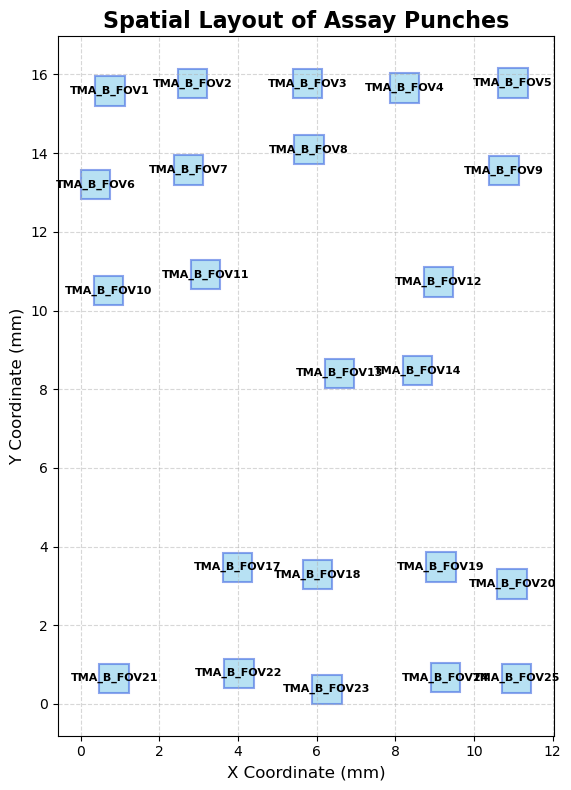

In [78]:
# Setup For Loops:
if TMA_Core == "A":
    outer_range = range(1, 26)   # 1–25 inclusive
    inner_range = range(1, 2)    # 1–2 inclusive

elif TMA_Core == "B":
    outer_range = list(range(1, 15)) + list(range(17, 26))
    inner_range = range(2, 3)    # 2–3 inclusive

elif TMA_Core == "C":
    outer_range = range(1, 21)   # 1–20 inclusive
    inner_range = range(3, 4)    # 3–4 inclusive


# 2. Process the data to get rectangle coordinates
data=[]
TMA_CORE=["A","B","C"]
for i in outer_range:
    for j in inner_range:
        rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"
        results = find_area_mRNA_global_coords(adata_rna, rna_sample_id)
        dataset="mRNA"

        # Calculate length of dimensions of the samples
        x_length = results["X Max"] - results["X Min"]
        y_length = results["Y Max"] - results["Y Min"]

        data.append({
            "sample_id": rna_sample_id,
            "X Min (mm)": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length,
            "Dataset": dataset
        })

global_rectangles_mRNA = pd.DataFrame(data).dropna()


# 3. Display the resulting DataFrame
print("Calculated Rectangle Coordinates and Dimensions:")
print(global_rectangles_mRNA)

# 5. Translation steps-  Since the protein and mRNA use different global coordinate systems. This step sets the x and y mins as zero
# Find the global minima
global_min_x = global_rectangles_mRNA["X Min (mm)"].min()
global_min_y = global_rectangles_mRNA["Y Min (mm)"].min()

# Create translated DataFrame (same format as original)
translated_global_rectangles = global_rectangles_mRNA.copy()

# Translate coordinates
translated_global_rectangles["X Min (mm)"] = (
    translated_global_rectangles["X Min (mm)"] - global_min_x
)
translated_global_rectangles["X Max (mm)"] = (
    translated_global_rectangles["X Max (mm)"] - global_min_x
)
translated_global_rectangles["Y Min (mm)"] = (
    translated_global_rectangles["Y Min (mm)"] - global_min_y
)
translated_global_rectangles["Y Max (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - global_min_y
)

# Lengths remain the same after translation
# but we can recompute to avoid rounding drift
translated_global_rectangles["X Length(mm)"] = (
    translated_global_rectangles["X Max (mm)"] - translated_global_rectangles["X Min (mm)"]
)
translated_global_rectangles["Y Length (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - translated_global_rectangles["Y Min (mm)"]
)
plot_spatial_rectangles_mRNA2(translated_global_rectangles)

translated_global_rectangles_mRNA=translated_global_rectangles

## Main Execution (Protein)

Calculated Rectangle Coordinates and Dimensions:
   sample_id  X Min (mm)  X Max (mm)  Y Min (mm)  Y Max (mm)  X Length(mm)  \
0     c_2_1_    9.973560   10.720824    0.133680    0.883800      0.747264   
1     c_2_2_    7.640048    8.388320    0.001680    0.751464      0.748272   
2     c_2_3_    5.011552    5.758984    0.237184    0.986800      0.747432   
3     c_2_4_    2.593208    3.342152    0.385184    1.133792      0.748944   
4     c_2_5_   -0.751128   -0.002016    0.211848    0.961128      0.749112   
5     c_2_6_    9.982392   10.729488    3.069344    3.819128      0.747096   
6     c_2_7_    7.617880    8.365816    2.700512    3.449960      0.747936   
7     c_2_8_    4.670720    5.418488    2.445848    3.195128      0.747768   
8     c_2_9_   -0.222456    0.526488    2.969344    3.718792      0.748944   
9    c_2_10_    9.974040   10.723152    5.788512    6.537960      0.749112   
10   c_2_11_    7.725880    8.474656    5.430512    6.180800      0.748776   
11   c_2_12_   

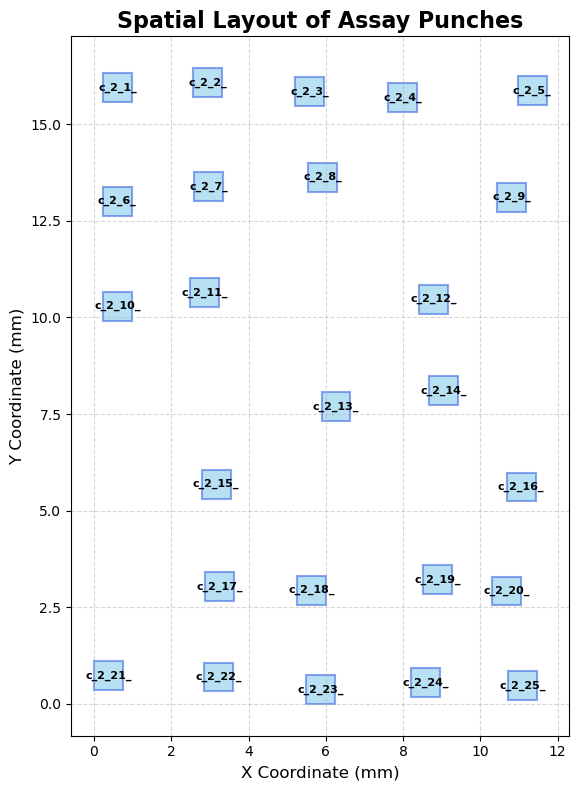

In [79]:
# Setup For Loops:
if TMA_Core == "A":
    outer_range = range(1, 26)   # 1–25 inclusive
    inner_range = range(1, 2)    # 1–2 inclusive

elif TMA_Core == "B":
    outer_range = range(1, 26)   # 1–25 inclusive
    inner_range = range(2, 3)    # 2–3 inclusive

elif TMA_Core == "C":
    outer_range = range(3, 21)   # 3–20 inclusive
    inner_range = range(3, 4)    # 3–4 inclusive



# 1. Process the data to get rectangle coordinates
data = []
for i in outer_range:
    for j in inner_range:
        dataset="Protein"
        sample_id = f"c_{j}_{i}_"
        results = find_area_protein_global_coords_optimized(adata, sample_id)

        # Calculate length of dimensions of the samples
        x_length = results["X Max"] - results["X Min"]
        y_length = results["Y Max"] - results["Y Min"]

        data.append({
            "sample_id": sample_id,
            "X Min (mm)": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length,
            "Dataset": dataset
        })

global_rectangles_protein = pd.DataFrame(data).dropna()


# 2. Display the resulting DataFrame
print("Calculated Rectangle Coordinates and Dimensions:")
print(global_rectangles_protein)

aligned_protein = flip_axes(global_rectangles_protein, flip_x=True, flip_y=True)

# display(aligned_protein)

plot_spatial_rectangles_protein(aligned_protein)

## Protein and mRNA Combined Plot Overlay

,sample_id,X Min (mm),X Max (mm),Y Min (mm),Y Max (mm),X Length(mm),Y Length (mm),Dataset
0,c_2_1_,0.240168,0.987432,15.567328,16.317448,0.747264,0.750120,Protein
1,c_2_2_,2.572672,3.320944,15.699664,16.449448,0.748272,0.749784,Protein
2,c_2_3_,5.202008,5.949440,15.464328,16.213944,0.747432,0.749616,Protein
3,c_2_4_,7.618840,8.367784,15.317336,16.065944,0.748944,0.748608,Protein
4,c_2_5_,10.963008,11.712120,15.490000,16.239280,0.749112,0.749280,Protein
5,c_2_6_,0.231504,0.978600,12.632000,13.381784,0.747096,0.749784,Protein
6,c_2_7_,2.595176,3.343112,13.001168,13.750616,0.747936,0.749448,Protein
7,c_2_8_,5.542504,6.290272,13.256000,14.005280,0.747768,0.749280,Protein
8,c_2_9_,10.434504,11.183448,12.732336,13.481784,0.748944,0.749448,Protein
9,c_2_10_,0.237840,0.986952,9.913168,10.662616,0.749112,0.749448,Protein


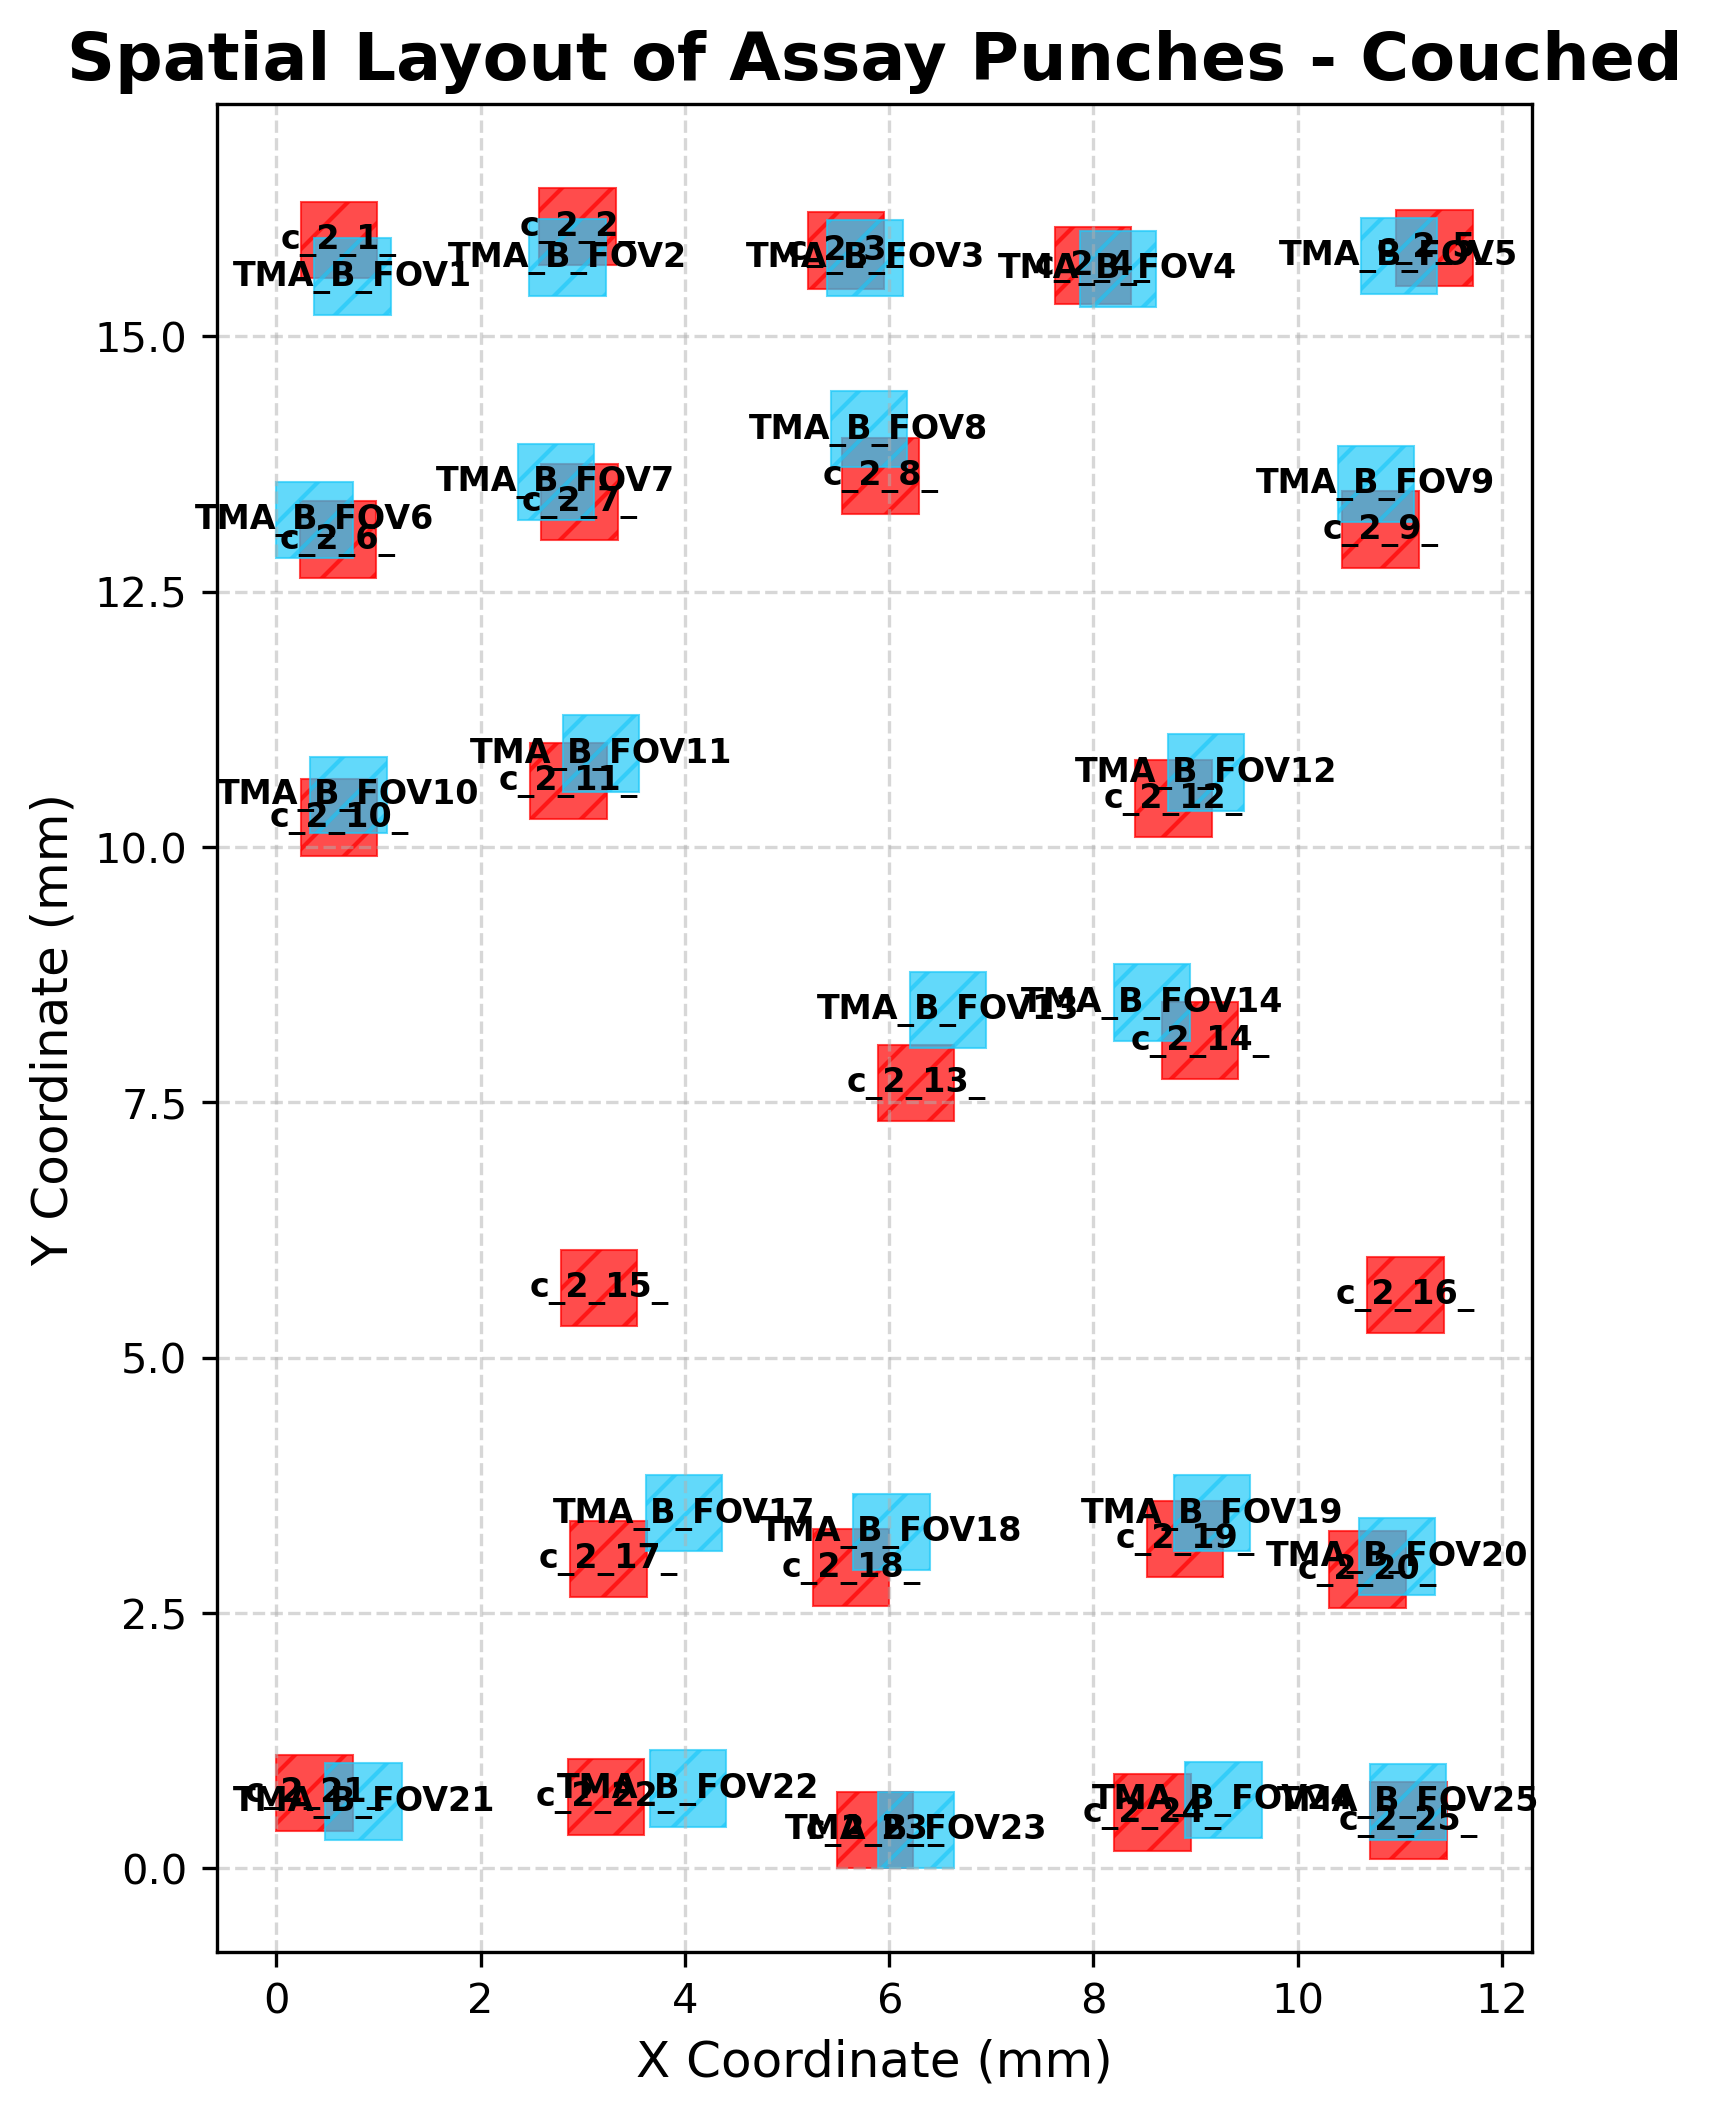

In [80]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


translated_global_rectangles_mRNA=translated_global_rectangles

# Combine the columns on the same dataframe 
Combined_DataFrame = pd.concat([aligned_protein, translated_global_rectangles_mRNA], ignore_index=True)
display(Combined_DataFrame)

def plot_spatial_rectangles_combined(dataframe, ax=None):
    """
    Plots the rectangular areas defined in the dataframe, with colors based on dataset type.

    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min, X/Y Length, sample_id, and dataset.
        ax (matplotlib.axes.Axes, optional): Matplotlib Axes object to plot on. 
                                             If None, a new figure and axes are created.
    """
    # Create a new figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        show_plot = True
    else:
        show_plot = False

    # Define colors for each dataset type
    color_map = {
        "Protein": {
            "edgecolor": "#ff0000",
            "facecolor": "#ff0000",  # bright red
            "alpha": 0.7,
            "linewidth": 0.5,
            "hatch": "//"
        },
        "mRNA": {
            "edgecolor": "#1FC9F9",
            "facecolor": "#1FC9F9",  # soft blue
            "alpha": 0.7,
            "linewidth": 0.5,
            "hatch": "//"
        }
    }

    for _, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]
        dataset_type = row["Dataset"]
    
        colors = color_map.get(dataset_type, {
            "edgecolor": "black",
            "facecolor": "gray",
            "alpha": 0.6,
            "linewidth": 1.0,
            "hatch": ""
        })
    
        rect = patches.Rectangle(
            (x_min, y_min),
            x_length,
            y_length,
            linewidth=colors["linewidth"],
            edgecolor=colors["edgecolor"],
            facecolor=colors["facecolor"],
            hatch=colors["hatch"],
            alpha=colors["alpha"]
        )
        ax.add_patch(rect)
        ax.text(
            x_min + x_length / 2,
            y_min + y_length / 2,
            sample_id,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold'
        )

    # Styling
    ax.set_title('Spatial Layout of Assay Punches - Couched', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()
    ax.grid(True, linestyle='--', alpha=0.5)

    if show_plot:
        plt.tight_layout()
        plt.show()

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
plot_spatial_rectangles_combined(Combined_DataFrame, ax=ax)

